# Adaptive Learning Core - Interactive Demo

This notebook demonstrates the core algorithms of the Adaptive Learning System:

1. **Mastery Update** (Equation 3): How learner mastery evolves based on quiz performance
2. **Knowledge Decay** (Equations 7-8): Ebbinghaus forgetting curve implementation
3. **Card Selection** (Equations 4-5): Probability-based card selection
4. **Item Response Theory**: 1PL, 2PL, 3PL models for question evaluation
5. **Bloom's Taxonomy**: Cognitive level classification

## Setup

First, let's import the necessary modules.

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta, timezone

# Models
from adaptive_learning_core import (
    Card, CardState, Question, BloomLevel,
    Module, ModuleProgress, ModuleStatus,
    LearnerProfile, PacePreference, LearningGoal,
)

# Algorithms
from adaptive_learning_core import (
    MasteryUpdater, MasteryUpdateConfig,
    KnowledgeDecay, DecayAlgoConfig,
    CardSelector, CardSelectionConfig,
)

# IRT
from adaptive_learning_core import (
    Rasch1PL, Model2PL, Model3PL, ItemParameters,
)

# Bloom
from adaptive_learning_core import (
    BLOOM_LEVEL_INFO, HeuristicBloomClassifier,
)

print("Adaptive Learning Core loaded successfully!")

Adaptive Learning Core loaded successfully!


## 1. Mastery Update Algorithm (Equation 3)

The mastery update rule governs how a learner's understanding evolves:

$$M(c) = M(c) + \alpha \times C_{c,q} \times \delta$$

Where:
- $M(c)$ = mastery score for card $c$
- $\alpha$ = progression rate (from pace preference: slow=0.05, medium=0.10, fast=0.15)
- $C_{c,q}$ = contribution weight of card $c$ to question $q$
- $\delta$ = +1 (correct) or -1 (incorrect)

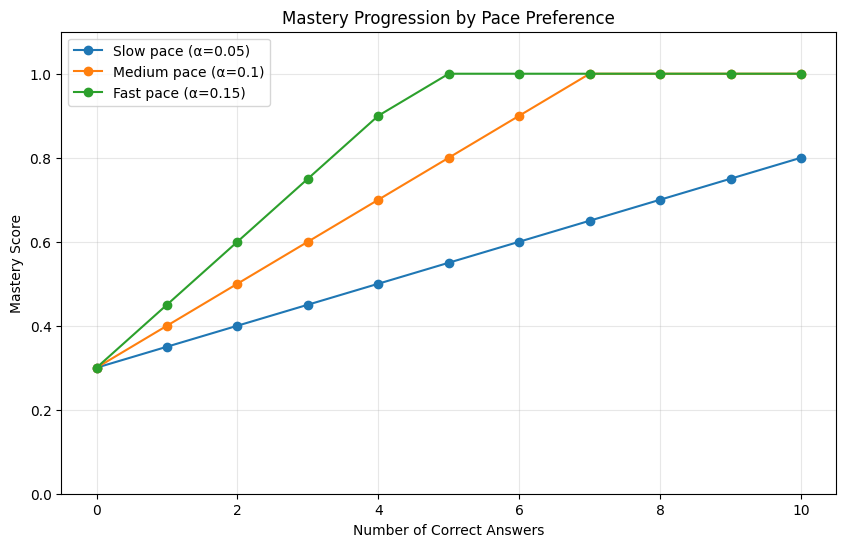

In [2]:
# Create a sample question linked to a card
question = Question(
    id="q1",
    module_id="mod1",
    stem="What is the powerhouse of the cell?",
    correct_answer="Mitochondria",
    distractors=["Nucleus", "Ribosome", "Golgi apparatus"],
    explanation="Mitochondria produce ATP through cellular respiration.",
    bloom_level=BloomLevel.REMEMBER,
    linked_card_ids=["card_1"],
    card_contribution_weights={"card_1": 1.0},
)

# Create card state
card_state = CardState(
    card_id="card_1",
    learner_id="learner_1",
    mastery_score=0.3,
)

updater = MasteryUpdater()

# Simulate progression over multiple correct answers
paces = ["slow", "medium", "fast"]
scores_over_time = {pace: [0.3] for pace in paces}

for pace in paces:
    card_state.mastery_score = 0.3
    for _ in range(10):
        result = updater.update_single(card_state, question, is_correct=True, pace=pace)
        scores_over_time[pace].append(card_state.mastery_score)

# Plot
plt.figure(figsize=(10, 6))
for pace, scores in scores_over_time.items():
    plt.plot(scores, label=f'{pace.capitalize()} pace (α={updater.config.get_alpha(pace)})', marker='o')

plt.xlabel('Number of Correct Answers')
plt.ylabel('Mastery Score')
plt.title('Mastery Progression by Pace Preference')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.1)
plt.show()

## 2. Knowledge Decay (Equations 7-8)

The system implements Ebbinghaus's Forgetting Curve:

$$M(c) = M(c) \times e^{-\beta \times \lambda \times \tau}$$

Where:
- $\beta$ = base decay parameter (default: 0.1)
- $\lambda$ = decay multiplier (0, 1, or 2 depending on time context)
- $\tau$ = time elapsed in hours

The decay multiplier $\lambda$:
- $\lambda = 0$ if $\tau < 4$ hours (no decay)
- $\lambda = 1$ if $\tau \geq 4$ hours and same calendar date
- $\lambda = 2$ if $\tau \geq 4$ hours and different calendar date

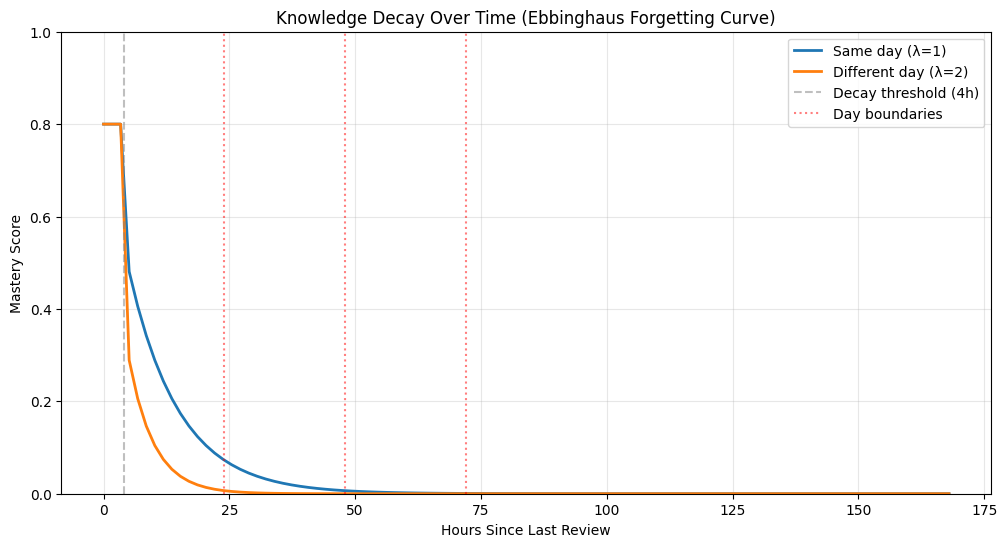

After 24 hours (same day):      0.073
After 24 hours (different day): 0.007
After 7 days:                   0.000


In [3]:
decay = KnowledgeDecay()

# Calculate decay over time
hours = np.linspace(0, 168, 100)  # 0 to 7 days
initial_mastery = 0.8

# Same day decay (λ=1 after 4 hours)
same_day_scores = []
for h in hours:
    if h < 4:
        same_day_scores.append(initial_mastery)
    else:
        same_day_scores.append(decay.preview_decay(initial_mastery, h, same_day=True))

# Different day decay (λ=2 after 4 hours)
diff_day_scores = []
for h in hours:
    if h < 4:
        diff_day_scores.append(initial_mastery)
    else:
        diff_day_scores.append(decay.preview_decay(initial_mastery, h, same_day=False))

# Plot
plt.figure(figsize=(12, 6))
plt.plot(hours, same_day_scores, label='Same day (λ=1)', linewidth=2)
plt.plot(hours, diff_day_scores, label='Different day (λ=2)', linewidth=2)
plt.axvline(x=4, color='gray', linestyle='--', alpha=0.5, label='Decay threshold (4h)')
plt.axvline(x=24, color='red', linestyle=':', alpha=0.5, label='Day boundaries')
plt.axvline(x=48, color='red', linestyle=':', alpha=0.5)
plt.axvline(x=72, color='red', linestyle=':', alpha=0.5)

plt.xlabel('Hours Since Last Review')
plt.ylabel('Mastery Score')
plt.title('Knowledge Decay Over Time (Ebbinghaus Forgetting Curve)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 1)
plt.show()

print(f"After 24 hours (same day):      {decay.preview_decay(0.8, 24, same_day=True):.3f}")
print(f"After 24 hours (different day): {decay.preview_decay(0.8, 24, same_day=False):.3f}")
print(f"After 7 days:                   {decay.preview_decay(0.8, 168, same_day=False):.3f}")

## 3. Card Selection Algorithm (Equations 4-5)

Cards are selected probabilistically based on mastery:

$$P(c) = \frac{1 - M(c) + \gamma}{Z}$$

Where:
- $P(c)$ = probability of selecting card $c$
- $M(c)$ = current mastery score
- $\gamma$ = prior probability for unseen cards (default: 0.1)
- $Z$ = normalization constant

Gamma boosting (Equation 5) encourages new material when performing well:
$$\gamma_{new} = \gamma \times \delta \quad \text{when score} > \theta$$

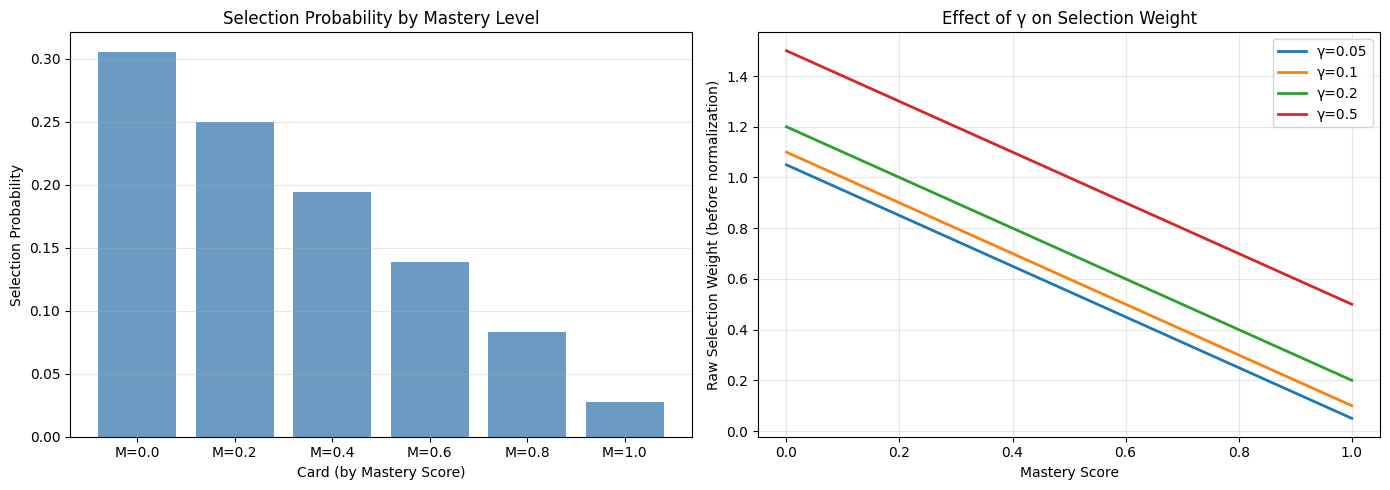


Gamma Boosting Demo:
Initial gamma: 0.1
After 90% quiz: 0.150 (boosted!)
After 70% quiz: 0.100 (no boost)


In [4]:
# Create cards with varying mastery levels
card_states = [
    CardState(card_id=f"card_{i}", learner_id="learner_1", mastery_score=m)
    for i, m in enumerate([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
]

selector = CardSelector()
probs = selector.calculate_probabilities(card_states)

# Visualize selection probabilities
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Probability vs Mastery
masteries = [s.mastery_score for s in card_states]
probabilities = [probs[s.card_id] for s in card_states]

axes[0].bar(range(len(card_states)), probabilities, color='steelblue', alpha=0.8)
axes[0].set_xticks(range(len(card_states)))
axes[0].set_xticklabels([f'M={m:.1f}' for m in masteries])
axes[0].set_xlabel('Card (by Mastery Score)')
axes[0].set_ylabel('Selection Probability')
axes[0].set_title('Selection Probability by Mastery Level')
axes[0].grid(True, alpha=0.3, axis='y')

# Right: Effect of gamma on selection
gammas = [0.05, 0.1, 0.2, 0.5]
mastery_range = np.linspace(0, 1, 50)

for gamma in gammas:
    # Simplified probability calculation (without normalization)
    raw_probs = 1 - mastery_range + gamma
    axes[1].plot(mastery_range, raw_probs, label=f'γ={gamma}', linewidth=2)

axes[1].set_xlabel('Mastery Score')
axes[1].set_ylabel('Raw Selection Weight (before normalization)')
axes[1].set_title('Effect of γ on Selection Weight')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Demonstrate gamma boosting
print("\nGamma Boosting Demo:")
print(f"Initial gamma: {selector.config.gamma}")
print(f"After 90% quiz: {selector.maybe_boost_gamma(0.1, 0.9):.3f} (boosted!)")
print(f"After 70% quiz: {selector.maybe_boost_gamma(0.1, 0.7):.3f} (no boost)")

## 4. Item Response Theory (IRT) Models

IRT models estimate the probability of a correct response based on learner ability and item characteristics:

**1PL (Rasch):**
$$P(X=1|\theta, b) = \frac{1}{1 + e^{-(\theta - b)}}$$

**2PL:**
$$P(X=1|\theta, a, b) = \frac{1}{1 + e^{-a(\theta - b)}}$$

**3PL:**
$$P(X=1|\theta, a, b, c) = c + \frac{1-c}{1 + e^{-a(\theta - b)}}$$

Where:
- $\theta$ = learner ability
- $b$ = item difficulty
- $a$ = discrimination (how well the item differentiates abilities)
- $c$ = guessing parameter

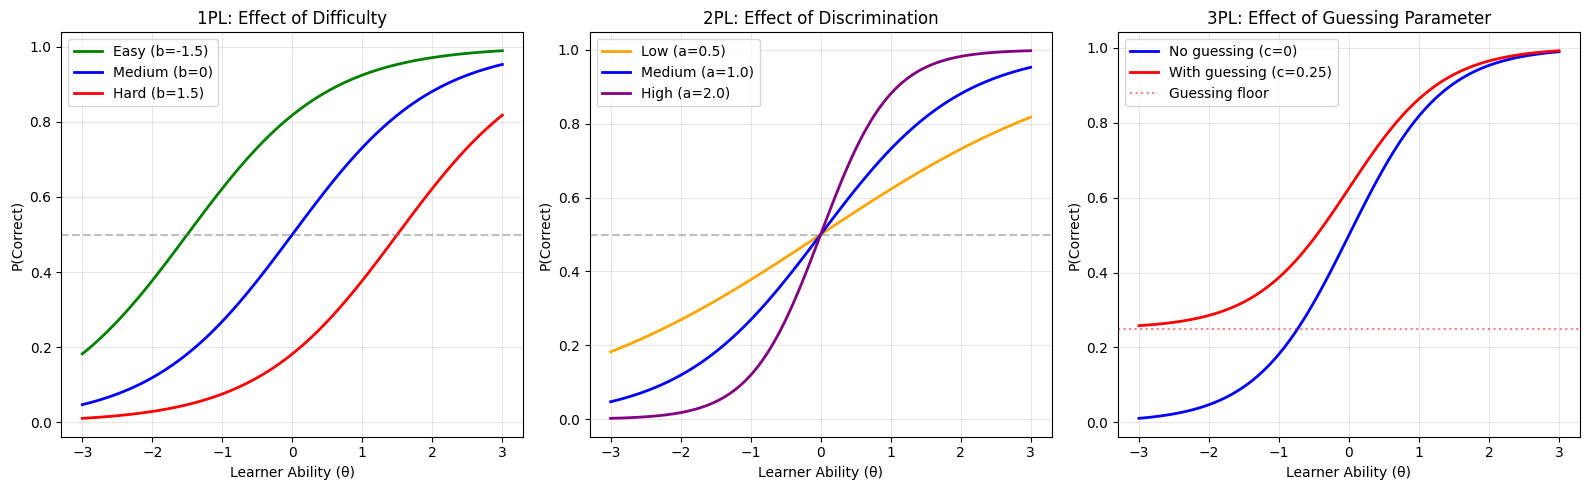

In [5]:
# Create IRT models
rasch = Rasch1PL()
model_2pl = Model2PL()
model_3pl = Model3PL()

# Create items with different parameters
easy_item = ItemParameters(item_id="easy", difficulty=-1.5, discrimination=1.0, guessing=0.0)
medium_item = ItemParameters(item_id="medium", difficulty=0.0, discrimination=1.0, guessing=0.0)
hard_item = ItemParameters(item_id="hard", difficulty=1.5, discrimination=1.0, guessing=0.0)

# Items with different discrimination
low_disc_item = ItemParameters(item_id="low_disc", difficulty=0.0, discrimination=0.5, guessing=0.0)
high_disc_item = ItemParameters(item_id="high_disc", difficulty=0.0, discrimination=2.0, guessing=0.0)

# Item with guessing
guessing_item = ItemParameters(item_id="guessing", difficulty=0.0, discrimination=1.5, guessing=0.25)

theta_range = np.linspace(-3, 3, 100)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Different difficulties (1PL)
for item, label, color in [(easy_item, 'Easy (b=-1.5)', 'green'),
                           (medium_item, 'Medium (b=0)', 'blue'),
                           (hard_item, 'Hard (b=1.5)', 'red')]:
    probs = [rasch.probability(t, item) for t in theta_range]
    axes[0].plot(theta_range, probs, label=label, color=color, linewidth=2)

axes[0].set_xlabel('Learner Ability (θ)')
axes[0].set_ylabel('P(Correct)')
axes[0].set_title('1PL: Effect of Difficulty')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

# Plot 2: Different discrimination (2PL)
for item, label, color in [(low_disc_item, 'Low (a=0.5)', 'orange'),
                           (medium_item, 'Medium (a=1.0)', 'blue'),
                           (high_disc_item, 'High (a=2.0)', 'purple')]:
    probs = [model_2pl.probability(t, item) for t in theta_range]
    axes[1].plot(theta_range, probs, label=label, color=color, linewidth=2)

axes[1].set_xlabel('Learner Ability (θ)')
axes[1].set_ylabel('P(Correct)')
axes[1].set_title('2PL: Effect of Discrimination')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

# Plot 3: Guessing parameter (3PL)
no_guess = ItemParameters(item_id="no_guess", difficulty=0.0, discrimination=1.5, guessing=0.0)
with_guess = ItemParameters(item_id="with_guess", difficulty=0.0, discrimination=1.5, guessing=0.25)

probs_no_guess = [model_3pl.probability(t, no_guess) for t in theta_range]
probs_with_guess = [model_3pl.probability(t, with_guess) for t in theta_range]

axes[2].plot(theta_range, probs_no_guess, label='No guessing (c=0)', color='blue', linewidth=2)
axes[2].plot(theta_range, probs_with_guess, label='With guessing (c=0.25)', color='red', linewidth=2)
axes[2].axhline(y=0.25, color='red', linestyle=':', alpha=0.5, label='Guessing floor')

axes[2].set_xlabel('Learner Ability (θ)')
axes[2].set_ylabel('P(Correct)')
axes[2].set_title('3PL: Effect of Guessing Parameter')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Bloom's Taxonomy

Questions are classified by cognitive complexity using Bloom's Taxonomy (revised, 2001):

| Level | Name | Description | Stereotype |
|-------|------|-------------|------------|
| 1 | Remember | Recall facts | Novice |
| 2 | Understand | Explain ideas | Beginner |
| 3 | Apply | Use in new situations | Intermediate |
| 4 | Analyze | Draw connections | Advanced |
| 5 | Evaluate | Justify decisions | Expert |
| 6 | Create | Produce new work | Expert |

In [6]:
# Display Bloom's Taxonomy levels
print("Bloom's Taxonomy Levels:\n")
print(f"{'Level':<6} {'Name':<12} {'Stereotype':<15} {'Example Verbs'}")
print("-" * 70)

stereotype_names = ["Novice", "Beginner", "Intermediate", "Advanced", "Expert"]

for level in BloomLevel:
    stereotype_idx = level.to_stereotype_level()
    verbs = ", ".join(level.action_verbs[:4])
    print(f"{level.value:<6} {level.name:<12} {stereotype_names[stereotype_idx]:<15} {verbs}")

Bloom's Taxonomy Levels:

Level  Name         Stereotype      Example Verbs
----------------------------------------------------------------------
1      REMEMBER     Novice          define, list, recall, identify
2      UNDERSTAND   Beginner        explain, describe, summarize, interpret
3      APPLY        Intermediate    apply, demonstrate, solve, use
4      ANALYZE      Advanced        analyze, compare, contrast, differentiate
5      EVALUATE     Expert          evaluate, judge, critique, justify
6      CREATE       Expert          create, design, develop, formulate


In [7]:
# Heuristic Bloom classification (no API key needed - keyword-based)
classifier = HeuristicBloomClassifier()

sample_questions = [
    "Define the term 'mitosis'.",
    "Explain how DNA replication works.",
    "Calculate the probability of inheriting a recessive trait.",
    "Compare and contrast mitosis and meiosis.",
    "Evaluate the ethical implications of genetic engineering.",
    "Design an experiment to test Mendel's laws of inheritance.",
]

print("Heuristic Bloom Classification:\n")
for q in sample_questions:
    # Use classify_with_confidence() to get confidence scores
    result = classifier.classify_with_confidence(q)
    print(f"Q: {q}")
    print(f"   → {result.level.name} (confidence: {result.confidence:.2f})")
    print()

Heuristic Bloom Classification:

Q: Define the term 'mitosis'.
   → REMEMBER (confidence: 1.00)

Q: Explain how DNA replication works.
   → UNDERSTAND (confidence: 1.00)

Q: Calculate the probability of inheriting a recessive trait.
   → APPLY (confidence: 1.00)

Q: Compare and contrast mitosis and meiosis.
   → ANALYZE (confidence: 1.00)

Q: Evaluate the ethical implications of genetic engineering.
   → EVALUATE (confidence: 1.00)

Q: Design an experiment to test Mendel's laws of inheritance.
   → CREATE (confidence: 1.00)



## 6. Complete Learning Simulation

Let's simulate a complete learning session with all algorithms working together.

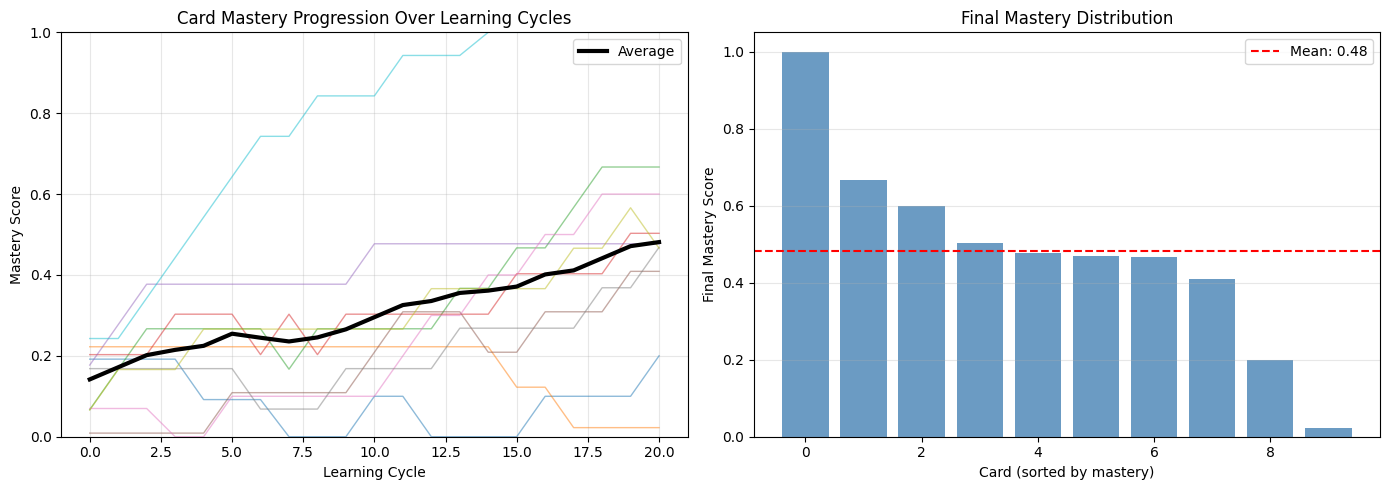


Simulation Summary:
  Learning cycles: 20
  Cards per cycle: 3
  Initial avg mastery: 0.142
  Final avg mastery: 0.481
  Improvement: +0.340


In [8]:
import random

# Setup
np.random.seed(42)
random.seed(42)

# Create 10 cards with initial mastery scores
n_cards = 10
card_states = [
    CardState(
        card_id=f"card_{i}",
        learner_id="learner_1",
        mastery_score=random.uniform(0, 0.3),
        times_seen=random.randint(0, 3),
    )
    for i in range(n_cards)
]

# Create questions (one per card)
questions = [
    Question(
        id=f"q_{i}",
        module_id="mod1",
        stem=f"Question about card {i}",
        correct_answer="Correct",
        distractors=["Wrong1", "Wrong2", "Wrong3"],
        explanation="Explanation",
        bloom_level=random.choice(list(BloomLevel)),
        linked_card_ids=[f"card_{i}"],
        card_contribution_weights={f"card_{i}": 1.0},
    )
    for i in range(n_cards)
]

# Initialize algorithms
selector = CardSelector()
updater = MasteryUpdater()
decay = KnowledgeDecay()

# Simulate learning cycles
n_cycles = 20
cards_per_cycle = 3
learner_ability = 0.7  # 70% chance of correct answer

# Track mastery over time
mastery_history = {state.card_id: [state.mastery_score] for state in card_states}
average_mastery_history = [np.mean([s.mastery_score for s in card_states])]

for cycle in range(n_cycles):
    # Select cards for this cycle
    result = selector.select_cards(card_states, n=cards_per_cycle)
    
    # Quiz on selected cards
    for card_id in result.selected_card_ids:
        state = next(s for s in card_states if s.card_id == card_id)
        question = next(q for q in questions if card_id in q.linked_card_ids)
        
        # Simulate answer (ability + some randomness based on mastery)
        is_correct = random.random() < (learner_ability + state.mastery_score * 0.2)
        
        # Update mastery
        updater.update_single(state, question, is_correct, pace="medium")
    
    # Record history
    for state in card_states:
        mastery_history[state.card_id].append(state.mastery_score)
    average_mastery_history.append(np.mean([s.mastery_score for s in card_states]))

# Visualize results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot individual card mastery
for card_id, history in mastery_history.items():
    axes[0].plot(history, alpha=0.5, linewidth=1)
axes[0].plot(average_mastery_history, color='black', linewidth=3, label='Average')
axes[0].set_xlabel('Learning Cycle')
axes[0].set_ylabel('Mastery Score')
axes[0].set_title('Card Mastery Progression Over Learning Cycles')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 1)

# Plot final mastery distribution
final_masteries = [s.mastery_score for s in card_states]
axes[1].bar(range(n_cards), sorted(final_masteries, reverse=True), color='steelblue', alpha=0.8)
axes[1].axhline(y=np.mean(final_masteries), color='red', linestyle='--', label=f'Mean: {np.mean(final_masteries):.2f}')
axes[1].set_xlabel('Card (sorted by mastery)')
axes[1].set_ylabel('Final Mastery Score')
axes[1].set_title('Final Mastery Distribution')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\nSimulation Summary:")
print(f"  Learning cycles: {n_cycles}")
print(f"  Cards per cycle: {cards_per_cycle}")
print(f"  Initial avg mastery: {average_mastery_history[0]:.3f}")
print(f"  Final avg mastery: {average_mastery_history[-1]:.3f}")
print(f"  Improvement: +{average_mastery_history[-1] - average_mastery_history[0]:.3f}")

## Summary

This notebook demonstrated the core algorithms of the Adaptive Learning System:

1. **Mastery Update**: Learner mastery evolves based on quiz performance with pace-dependent progression rates
2. **Knowledge Decay**: Mastery naturally decreases over time following the Ebbinghaus forgetting curve
3. **Card Selection**: Cards with lower mastery have higher selection probability, ensuring weak areas are practiced
4. **IRT Models**: Item Response Theory provides a mathematical framework for estimating question difficulty and learner ability
5. **Bloom's Taxonomy**: Questions are classified by cognitive complexity to match learner progression

For more details, see the [GitHub repository](https://github.com/emfrg/adaptive-learning-core).